In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

drive_dataset_path = "/content/drive/MyDrive/mars_classification_dataset_merged"
local_dataset_path = "/content/mars_classification_dataset_merged"

if os.path.exists(local_dataset_path):
    shutil.rmtree(local_dataset_path)

shutil.copytree(drive_dataset_path, local_dataset_path)

print("Dataset copied to:", local_dataset_path)

Dataset copied to: /content/mars_classification_dataset_merged


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
data_dir = "/content/mars_classification_dataset_merged"

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in os.listdir(os.path.join(data_dir, split)):
        folder_path = os.path.join(data_dir, split, cls)
        print(cls, ":", len(os.listdir(folder_path)))


TRAIN
sand : 1254
rocky_terrain : 5838
soil : 4036

VAL
sand : 269
rocky_terrain : 1251
soil : 867

TEST
sand : 270
rocky_terrain : 1254
soil : 866


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "val"),
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "test"),
    transform=val_test_transform
)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['rocky_terrain', 'sand', 'soil']
Number of classes: 3


In [ ]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [ ]:
num_epochs = 10
patience = 3

best_val_acc = 0
epochs_without_improvement = 0

train_losses = []
val_losses = []
val_accuracies = []

best_model_path = "/content/drive/MyDrive/best_mars_resnet50_3class_model.pth"

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "best_val_acc": best_val_acc
        }, best_model_path)

        print("Best model saved.")
    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= patience:
        print("Early stopping triggered.")
        break

    print("-" * 40)


Epoch 1/10


Validation: 100%|██████████| 38/38 [00:36<00:00,  1.04it/s]


Train Loss: 0.3938
Train Accuracy: 85.16%
Val Loss: 0.2087
Val Accuracy: 92.79%
Best model saved.
----------------------------------------

Epoch 2/10


Validation: 100%|██████████| 38/38 [00:34<00:00,  1.09it/s]


Train Loss: 0.2243
Train Accuracy: 91.39%
Val Loss: 0.1923
Val Accuracy: 92.46%
No improvement for 1 epoch(s).
----------------------------------------

Epoch 3/10


Validation: 100%|██████████| 38/38 [00:35<00:00,  1.07it/s]


Train Loss: 0.2037
Train Accuracy: 91.79%
Val Loss: 0.1938
Val Accuracy: 92.38%
No improvement for 2 epoch(s).
----------------------------------------

Epoch 4/10


Validation: 100%|██████████| 38/38 [00:33<00:00,  1.14it/s]

Train Loss: 0.1832
Train Accuracy: 92.83%
Val Loss: 0.1924
Val Accuracy: 92.67%
No improvement for 3 epoch(s).
Early stopping triggered.


In [ ]:
checkpoint = torch.load(best_model_path)

model.load_state_dict(checkpoint["model_state_dict"])
class_names = checkpoint["class_names"]

model = model.to(device)
model.eval()

print("Best model loaded.")
print("Best Validation Accuracy:", checkpoint["best_val_acc"])
print("Classes:", class_names)

Best model loaded.
Best Validation Accuracy: 92.79430247172182
Classes: ['rocky_terrain', 'sand', 'soil']


In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"Test Accuracy: {test_accuracy:.2f}%")

Testing: 100%|██████████| 38/38 [00:34<00:00,  1.09it/s]

Test Accuracy: 92.22%


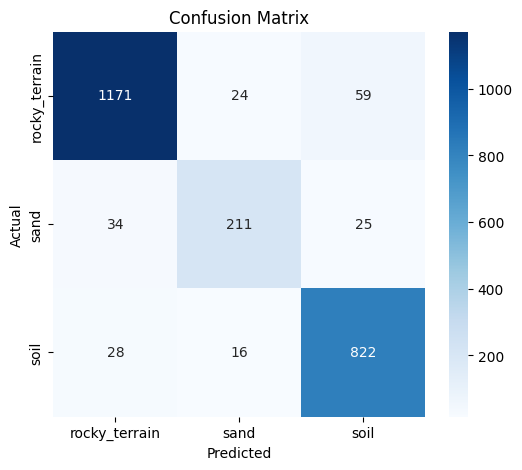

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

               precision    recall  f1-score   support

rocky_terrain       0.95      0.93      0.94      1254
         sand       0.84      0.78      0.81       270
         soil       0.91      0.95      0.93       866

     accuracy                           0.92      2390
    macro avg       0.90      0.89      0.89      2390
 weighted avg       0.92      0.92      0.92      2390



In [ ]:
model_save_path = "/content/drive/MyDrive/mars_resnet50_3class_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names
}, model_save_path)

print("Model saved at:", model_save_path)

Model saved at: /content/drive/MyDrive/mars_resnet50_3class_model.pth


In [ ]:
def predict_image(image_path, model, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image_tensor = val_test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score

Saving NLA_402468453EDR_F0043474NCAM00317M1.JPG to NLA_402468453EDR_F0043474NCAM00317M1.JPG


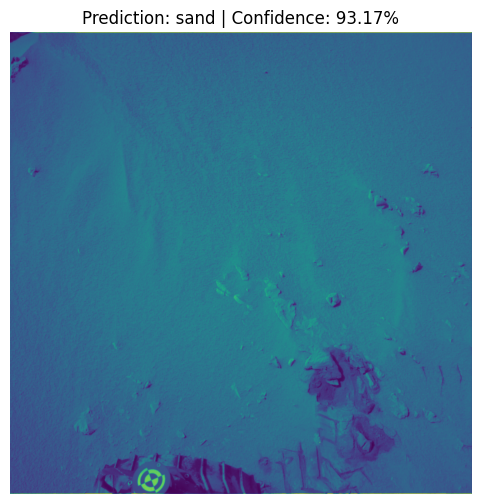

Predicted Terrain: sand
Confidence: 93.17%


In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

prediction, confidence = predict_image(image_path, model, class_names)

img = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {prediction} | Confidence: {confidence:.2f}%")
plt.show()

print("Predicted Terrain:", prediction)
print(f"Confidence: {confidence:.2f}%")